In [26]:
import ee
import os
import geemap
import pandas as p
import geopandas as gpd
from pathlib import Path
import sys
import importlib
import json
import matplotlib.pyplot as plt
import numpy as np


In [2]:
PROJECT_ROOT = Path().resolve().parent

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

True

In [ ]:
ee.Authenticate()



Successfully saved authorization token.


KeyError: 'EE_PROJECT'

In [3]:
ee.Initialize(project=os.environ["EE_PROJECT"])

In [4]:

sys.path.append(str(PROJECT_ROOT / "src"))

from gee_utils import create_images_for_all_locations, get_samples


In [5]:
# Want to upload the sites.json to ee and then create image collection for each, clip to the bbox, need to select the dates for each location
# Could save the location in the json or just use the date from the points? 

# Then want to upload the point shapefiles and use those to sample the images for the matching date. Hmmm, should think about that. does each point need a date attribute - yes?
site_fp = PROJECT_ROOT / "configs" / "sites_test.json"
points_fp = PROJECT_ROOT / "configs" / "point_files" / "mula_points.shp"


In [41]:
image_collection = create_images_for_all_locations(sites_file= site_fp, project_root= PROJECT_ROOT)

Created image collection for: mula
Created image collection for: rawapening
Created image collection for: hartbeesport


In [44]:
samples = get_samples(merged_ic=image_collection,sites_file= site_fp, project_root=PROJECT_ROOT)

In [45]:
samples.tail()

,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,lat,lc,location,lon,obs_date
111,2261,1360,460,704,680,1103,2040,2301,2276,2465,-25.764169,0.0,hartbeesport,27.914911,2025-12-09
112,2643,2232,810,1124,1870,2140,2482,2742,2396,2645,-25.747466,0.0,hartbeesport,27.903837,2025-12-09
113,1113,909,1400,1608,1670,1761,1512,1502,1450,1298,-25.768336,0.0,hartbeesport,27.895905,2025-12-09
114,1392,630,193,389,224,796,2146,2485,2350,2702,-25.749659,0.0,hartbeesport,27.904933,2025-12-09
115,1581,846,244,443,308,848,1998,2393,2342,2499,-25.764827,0.0,hartbeesport,27.888010,2025-12-09


In [46]:
len(samples.loc[samples["lc"] == 0.0])

72

In [47]:
samples_outpath = PROJECT_ROOT / "outputs" / "sample_points.csv"

samples.to_csv(samples_outpath)

In [51]:
samples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   B11       116 non-null    int64  
 1   B12       116 non-null    int64  
 2   B2        116 non-null    int64  
 3   B3        116 non-null    int64  
 4   B4        116 non-null    int64  
 5   B5        116 non-null    int64  
 6   B6        116 non-null    int64  
 7   B7        116 non-null    int64  
 8   B8        116 non-null    int64  
 9   B8A       116 non-null    int64  
 10  lat       116 non-null    float64
 11  lc        114 non-null    float64
 12  location  116 non-null    object 
 13  lon       116 non-null    float64
 14  obs_date  116 non-null    object 
dtypes: float64(3), int64(10), object(2)
memory usage: 13.7+ KB


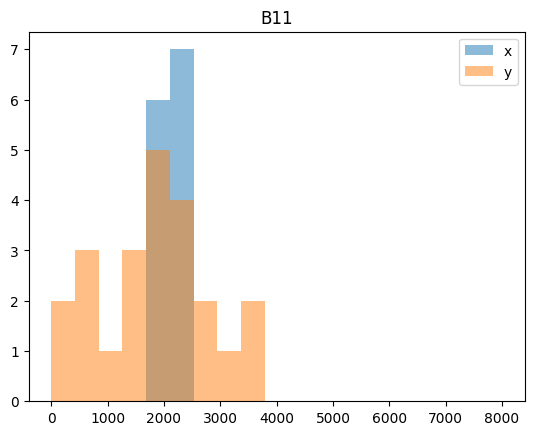

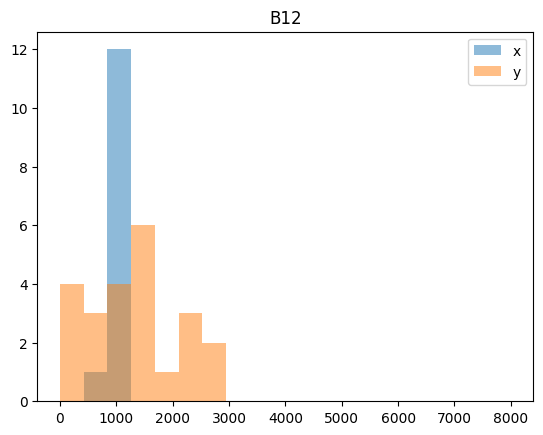

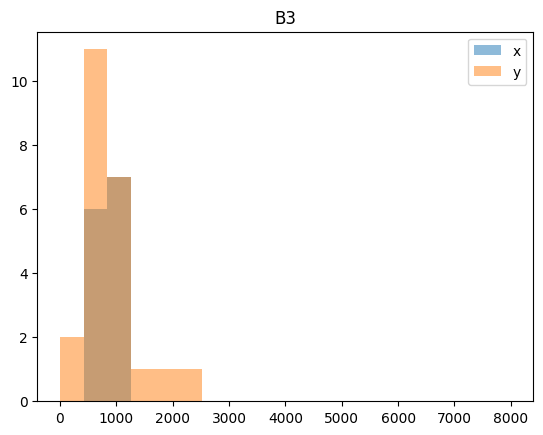

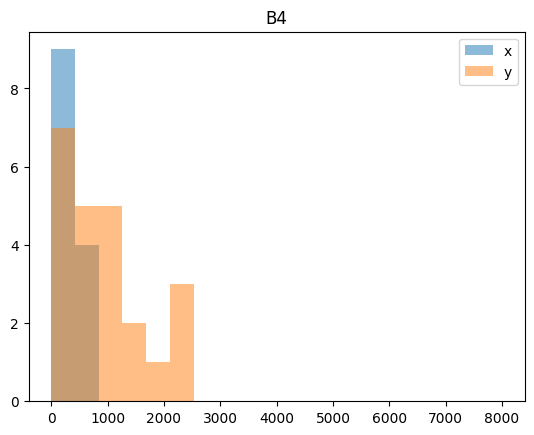

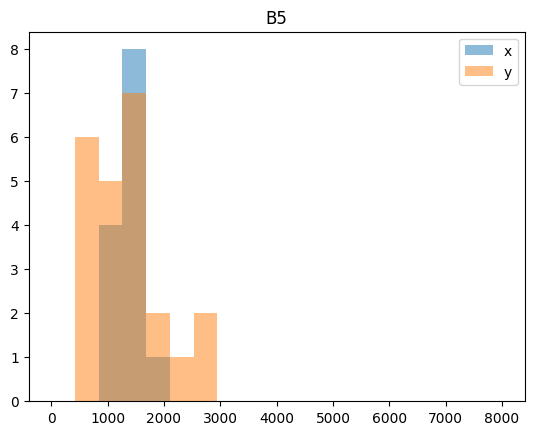

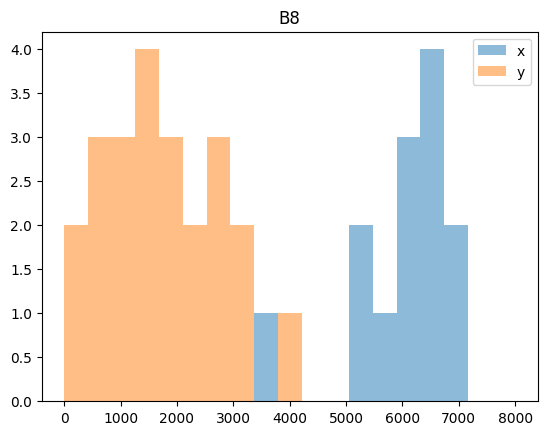

In [39]:
mula_wh_samples = samples.loc[(samples["location"]=="mula") & (samples["lc"]== 1.0), ["B11", "B12", "B3", "B4", "B5", "B8"]]
mula_non_wh_samples = samples.loc[(samples["location"]=="mula")& (samples["lc"]==0.0), ["B11", "B12", "B3", "B4", "B5", "B8"]]
bins = np.linspace(0,8000, 20)

for col in ["B11", "B12", "B3", "B4", "B5", "B8"]:
    plt.hist(mula_wh_samples[col], bins, alpha=0.5, label='x')
    plt.hist(mula_non_wh_samples[col], bins, alpha=0.5, label='y')
    plt.legend(loc='upper right')
    plt.title(f"{col}")
    plt.show()

